# Cancer PRO Decline Prediction: Exploratory Data Analysis (EDA)

**Project Context:**
This project is an ML mini-project inspired by the paper *Predicting Patient-Reported Outcome Physical Health Decline in Oncology Patients on Chemotherapy* (Ostberg & Peterson, Stanford CS229). The clinical objective is to predict whether cancer patients will experience a clinically meaningful decline in their self-reported physical health during chemotherapy.

Physical health is quantified using the **PROMIS Global Physical Health (GPH)** T-score:
- **Baseline GPH (`baseline_gph`)**: Measured prior to starting chemotherapy.
- **On-Chemotherapy GPH (`on_chemo_gph`)**: Measured during chemotherapy treatment.

**Target Outcomes:**
1. **`drop_outcome`**: Binary classification target. Equals `1` if a patient's GPH score falls by **10 or more points** during chemotherapy ($on\_chemo\_gph - baseline\_gph \le -10$), and `0` otherwise. A 10-point drop corresponds to 1 standard deviation, representing a clinically significant functional decline.
2. **`threshold_outcome`**: Binary classification target. Equals `1` if a patient's on-chemotherapy GPH score falls to or below **40** ($on\_chemo\_gph \le 40$), representing severe physical impairment.

**Important Data Leakage Warning:**
`on_chemo_gph` is collected *during* chemotherapy and is directly used to define both target outcomes. Therefore, **`on_chemo_gph` must NEVER be used as a predictive feature** in any model. Doing so would cause severe **data leakage** and render the model clinically invalid. Similarly, `patient_id` is merely a unique record identifier and not a predictive feature.

---

## Notebook Structure
1. **Load Data**: Verify dimensions, data types, initial records, and check for duplicates.
2. **Missing Values**: Count and percentage per column, visualized with a bar chart.
3. **Target Analysis**: Class balance of `drop_outcome` and `threshold_outcome`.
4. **Numeric Features**: Summary statistics and distribution histograms.
5. **Categorical Features**: Value counts and bar charts for clinical and demographic groups.
6. **Relationships with the Target**: Drop rates across clinical subgroups, and boxplots of baseline scores and age by outcome.
7. **Correlation Analysis**: Pearson correlations with `drop_outcome`, ranking of top 10 candidate features, and correlation heatmap.
8. **Distribution of Baseline vs. On-Chemo GPH**: Density comparison and scatter plot with clinical decision boundaries.


# 1. Load Data

### What this section does
In this section, we load the synthetic cancer patient dataset (`synthetic_chemo_pro_data.csv`) from `../data/raw/` into a pandas DataFrame. We then inspect the dataset dimensions, verify column data types, display sample records using `head()`, and check for any duplicate patient records.

### Why we do this
Before undertaking exploratory data analysis or building machine learning pipelines, it is crucial to ensure that the dataset has loaded correctly and to verify its structural integrity:
- We confirm that the cohort contains 1,800 patient records across 56 clinical and demographic variables.
- We check data types to distinguish continuous numerical measurements from categorical and identifier columns.
- We verify that there are no duplicate entries or repeated `patient_id` values, ensuring each row represents a distinct patient.


In [1]:
# Import the required data analysis and visualization libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style and aesthetics for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Ensure the output directory for report figures exists
os.makedirs("../reports/figures", exist_ok=True)
print("Environment initialized successfully. Figures will be saved to ../reports/figures/")


Environment initialized successfully. Figures will be saved to ../reports/figures/


In [2]:
# Load the synthetic cancer patient dataset
df = pd.read_csv("../data/raw/synthetic_chemo_pro_data.csv")

# Print the dimensions of the dataset
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Total patient records: {df.shape[0]:,}")
print(f"Total features and labels: {df.shape[1]}")


Dataset shape: 1800 rows, 56 columns
Total patient records: 1,800
Total features and labels: 56


In [3]:
# Display column data types summary
print("Data type breakdown across all columns:")
print(df.dtypes.value_counts())
print("\nFirst 10 columns and their data types:")
print(df.dtypes.head(10))


Data type breakdown across all columns:
int64      27
float64    20
object      9
Name: count, dtype: int64

First 10 columns and their data types:
patient_id         object
age                 int64
sex                object
race               object
insurance          object
marital_status     object
bmi               float64
smoking_status     object
cancer_type        object
stage               int64
dtype: object


In [4]:
# Display the first 5 rows of the dataset to inspect sample values
df.head()


,patient_id,age,sex,race,insurance,marital_status,bmi,smoking_status,cancer_type,stage,...,potassium_mmol_l,glucose_mg_dl,crp_mg_l,ldh_u_l,psa_ng_ml,baseline_gph,baseline_gmh,on_chemo_gph,drop_outcome,threshold_outcome
0,P0001,64,Male,Black,Private,Widowed,17.9,Never,Lymphoma,3,...,NaN,167.0,4.9,NaN,10.51,39.7,34.6,22.4,1,1
1,P0002,48,Female,White,Medicare,Divorced,27.7,Never,Lung,2,...,4.33,130.0,NaN,NaN,NaN,51.1,47.1,58.9,0,0
2,P0003,69,Male,White,Private,Married,24.7,Never,Prostate,2,...,4.11,87.0,7.4,306.0,NaN,52.2,39.3,68.7,0,0
3,P0004,71,Female,White,Medicare,Divorced,18.7,Former,Other,2,...,4.07,134.0,NaN,NaN,NaN,47.1,38.7,38.3,0,1
4,P0005,37,Male,Hispanic,Private,Single,29.9,Never,Lung,3,...,3.98,88.0,0.2,196.0,NaN,48.4,45.3,50.7,0,0


In [5]:
# Check for exact duplicate rows across all columns
exact_duplicates = df.duplicated().sum()
print("Number of exact duplicate rows in dataset:", exact_duplicates)

# Check for duplicate patient IDs
patient_id_duplicates = df["patient_id"].duplicated().sum()
print("Number of duplicate patient_id values:", patient_id_duplicates)


Number of exact duplicate rows in dataset: 0
Number of duplicate patient_id values: 0


# 2. Missing Values Analysis

### What this section does
In this section, we calculate the number and percentage of missing (`NaN`) values for each of the 56 columns in the dataset. We then isolate the columns that contain missing entries, present them in a sorted summary table, and visualize the missingness rates using a horizontal bar chart.

### Why we do this
Missing data is ubiquitous in clinical oncology and Electronic Health Records (EHR):
- Unlike clinical trials where every test is mandated, real-world oncology patients only undergo laboratory tests when clinically indicated by their treating oncologist.
- For instance, specialized tumor markers such as Prostate-Specific Antigen (`psa_ng_ml`) are clinically relevant only to prostate cancer patients and will be missing for other cancer types.
- Quantifying missingness allows us to plan appropriate preprocessing and imputation strategies (e.g., median imputation with missingness indicator flags) in subsequent modeling phases.


Total columns with missing values: 13 out of 56 columns
                  Missing Count  Missing Percentage (%)
psa_ng_ml                  1527                   84.83
crp_mg_l                    979                   54.39
ldh_u_l                     823                   45.72
bilirubin_mg_dl             582                   32.33
alt_u_l                     547                   30.39
glucose_mg_dl               508                   28.22
potassium_mmol_l            434                   24.11
albumin_g_dl                426                   23.67
platelets_k_ul              413                   22.94
sodium_mmol_l               408                   22.67
creatinine_mg_dl            389                   21.61
hemoglobin_g_dl             368                   20.44
wbc_k_ul                    367                   20.39


C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\2676103654.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


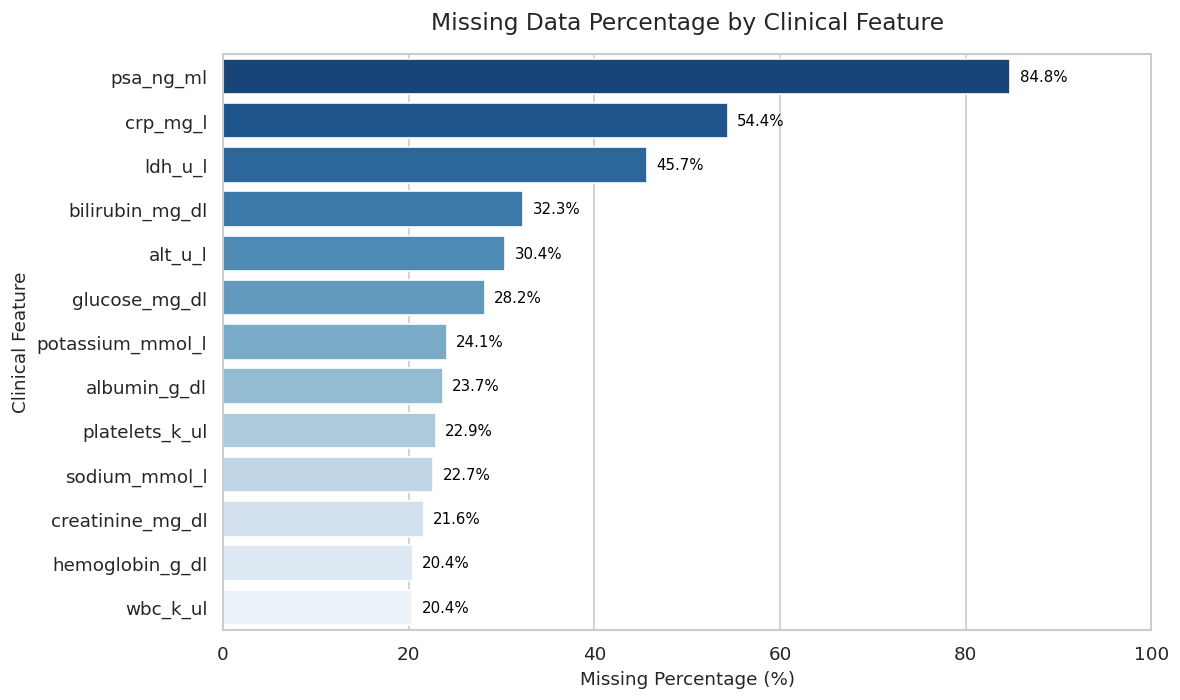

In [6]:
# Calculate missing count and percentage for every column in the dataset
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

# Build a summary DataFrame of missing values
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_pct
})

# Filter to keep only columns that have at least one missing value, sorted descending
missing_cols = missing_df[missing_df["Missing Count"] > 0].sort_values(
    by="Missing Percentage (%)", ascending=False
)

# Display the tabular summary of columns with missing data
print(f"Total columns with missing values: {len(missing_cols)} out of {df.shape[1]} columns")
print(missing_cols.round(2))

# Visualize the percentage of missing values per column
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(
    x=missing_cols["Missing Percentage (%)"],
    y=missing_cols.index,
    palette="Blues_r"
)

# Annotate each bar with its exact percentage
for index, value in enumerate(missing_cols["Missing Percentage (%)"]):
    bar_plot.text(value + 1.0, index, f"{value:.1f}%", va="center", fontsize=9, color="black")

plt.title("Missing Data Percentage by Clinical Feature", fontsize=14, pad=15)
plt.xlabel("Missing Percentage (%)", fontsize=11)
plt.ylabel("Clinical Feature", fontsize=11)
plt.xlim(0, 100)
plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/01_missing_values_summary.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: Which laboratory tests have the highest missingness (e.g., PSA, CRP, LDH)?*
- *Placeholder: Why does `psa_ng_ml` have ~85% missing values from a clinical perspective?*
- *Placeholder: Did any demographic features, baseline PROMIS scores, or outcome columns have missing values?*


# 3. Target Analysis: Class Balance

### What this section does
In this section, we analyze the class distributions of the two target outcome variables:
1. **`drop_outcome`**: Binary indicator where `1` denotes that the patient's PROMIS Global Physical Health score dropped by 10 or more points during chemotherapy.
2. **`threshold_outcome`**: Binary indicator where `1` denotes that the patient's on-chemotherapy PROMIS Global Physical Health score fell to or below 40.

### Why we do this
Examining class balance is a fundamental prerequisite for machine learning:
- **Imbalance impacts evaluation**: If positive events are relatively rare (e.g., ~20% for `drop_outcome`), raw classification accuracy is misleading. A naive baseline model predicting zero decline for all patients would score ~80% accuracy while failing to identify any high-risk patients.
- **Metric selection**: For imbalanced targets, models must be evaluated using **AUROC (Area Under the Receiver Operating Characteristic)**, **Precision-Recall AUC (PR-AUC)**, and **Recall / Sensitivity**.
- **Target definition contrast**: Comparing `drop_outcome` with `threshold_outcome` illustrates how a relative drop threshold differs from an absolute threshold in prevalence and clinical interpretation.


=== drop_outcome Class Distribution ===
Class 0 (No 10+ pt drop): 1,433 patients (79.61%)
Class 1 (Drop >= 10 pts): 367 patients (20.39%)

=== threshold_outcome Class Distribution ===
Class 0 (GPH > 40):       900 patients (50.00%)
Class 1 (GPH <= 40):      900 patients (50.00%)


C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\1956689831.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\1956689831.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["0: No Drop (<10 pts)", "1: Drop (>=10 pts)"])
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\1956689831.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\1956689831.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  

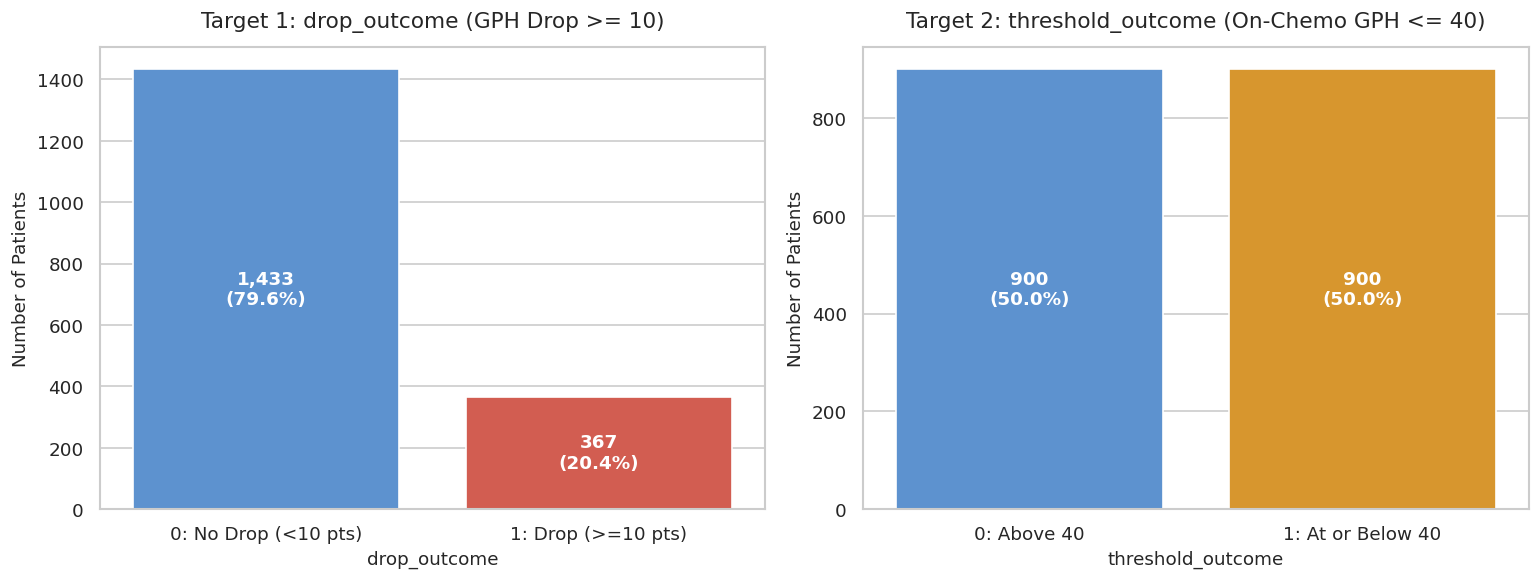

In [7]:
# Compute value counts and percentages for drop_outcome
drop_counts = df["drop_outcome"].value_counts().sort_index()
drop_pct = (df["drop_outcome"].value_counts(normalize=True).sort_index()) * 100

# Compute value counts and percentages for threshold_outcome
thresh_counts = df["threshold_outcome"].value_counts().sort_index()
thresh_pct = (df["threshold_outcome"].value_counts(normalize=True).sort_index()) * 100

# Print tabular summaries
print("=== drop_outcome Class Distribution ===")
print(f"Class 0 (No 10+ pt drop): {drop_counts[0]:,} patients ({drop_pct[0]:.2f}%)")
print(f"Class 1 (Drop >= 10 pts): {drop_counts[1]:,} patients ({drop_pct[1]:.2f}%)")

print("\n=== threshold_outcome Class Distribution ===")
print(f"Class 0 (GPH > 40):       {thresh_counts[0]:,} patients ({thresh_pct[0]:.2f}%)")
print(f"Class 1 (GPH <= 40):      {thresh_counts[1]:,} patients ({thresh_pct[1]:.2f}%)")

# Create side-by-side bar plots for target class balance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: drop_outcome class balance
sns.countplot(
    x="drop_outcome",
    data=df,
    ax=axes[0],
    palette=["#4a90e2", "#e74c3c"]
)
axes[0].set_title("Target 1: drop_outcome (GPH Drop >= 10)", fontsize=13, pad=12)
axes[0].set_xlabel("drop_outcome", fontsize=11)
axes[0].set_ylabel("Number of Patients", fontsize=11)
axes[0].set_xticklabels(["0: No Drop (<10 pts)", "1: Drop (>=10 pts)"])

# Annotate counts and percentages on bars
for p in axes[0].patches:
    height = p.get_height()
    pct = (height / len(df)) * 100
    axes[0].annotate(f"{int(height):,}\n({pct:.1f}%)",
                     (p.get_x() + p.get_width() / 2., height / 2),
                     ha="center", va="center", color="white", fontweight="bold", fontsize=11)

# Plot 2: threshold_outcome class balance
sns.countplot(
    x="threshold_outcome",
    data=df,
    ax=axes[1],
    palette=["#4a90e2", "#f39c12"]
)
axes[1].set_title("Target 2: threshold_outcome (On-Chemo GPH <= 40)", fontsize=13, pad=12)
axes[1].set_xlabel("threshold_outcome", fontsize=11)
axes[1].set_ylabel("Number of Patients", fontsize=11)
axes[1].set_xticklabels(["0: Above 40", "1: At or Below 40"])

# Annotate counts and percentages on bars
for p in axes[1].patches:
    height = p.get_height()
    pct = (height / len(df)) * 100
    axes[1].annotate(f"{int(height):,}\n({pct:.1f}%)",
                     (p.get_x() + p.get_width() / 2., height / 2),
                     ha="center", va="center", color="white", fontweight="bold", fontsize=11)

plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/02_target_class_balance.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: What is the positive class percentage for `drop_outcome`? Does this represent moderate class imbalance?*
- *Placeholder: What is the distribution for `threshold_outcome`? How does it differ from `drop_outcome`?*
- *Placeholder: What metric (e.g., Accuracy, ROC-AUC, PR-AUC, F1-score) should be the primary evaluation metric for `drop_outcome`?*


# 4. Numeric Features Analysis

### What this section does
In this section, we examine the central tendency, dispersion, and distribution shapes for key numeric clinical features. We generate a descriptive statistics table (mean, standard deviation, percentiles, minimum, maximum) and plot histograms with kernel density estimates (KDE) for representative variables spanning patient demographics (`age`, `bmi`), baseline patient-reported outcomes (`baseline_gph`, `baseline_gmh`), vital signs (`heart_rate`, `systolic_bp`, `weight_loss_pct_6m`), and routine laboratory tests (`hemoglobin_g_dl`, `albumin_g_dl`).

### Why we do this
- **Identify skewness and outliers**: Detecting skewed distributions (such as prior weight loss percentage) helps determine whether standard scaling, robust scaling, or log transformations are appropriate for linear models.
- **Physiological plausibility**: Checking minimum and maximum ranges ensures there are no corrupt sensor readings or unrealistic synthetic artifacts.
- **Reference benchmarks**: PROMIS scores are standardized T-scores normed to a mean of 50 and standard deviation of 10 in the US general population. Inspecting baseline scores shows how the pre-chemotherapy cancer cohort compares to the general population.


In [8]:
# Define representative numeric features spanning demographics, PRO scores, vitals, and labs
key_numeric_features = [
    "age", "bmi", "baseline_gph", "baseline_gmh",
    "weight_loss_pct_6m", "heart_rate", "systolic_bp",
    "hemoglobin_g_dl", "albumin_g_dl"
]

# Generate descriptive statistics table
print("=== Descriptive Statistics for Key Numeric Features ===")
stats_table = df[key_numeric_features].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
stats_table.round(2)


=== Descriptive Statistics for Key Numeric Features ===


,count,mean,std,min,25%,50%,75%,max
age,1800.0,59.49,12.00,21.00,52.00,60.00,67.00,90.00
bmi,1800.0,26.82,5.58,15.00,23.00,26.60,30.60,45.90
baseline_gph,1800.0,44.50,7.94,16.00,39.10,44.40,49.80,66.30
baseline_gmh,1800.0,43.26,8.02,18.00,37.80,43.30,48.70,70.00
weight_loss_pct_6m,1800.0,4.06,2.92,0.00,1.70,3.90,6.10,15.20
heart_rate,1800.0,82.01,10.33,46.00,75.00,82.00,89.00,120.00
systolic_bp,1800.0,125.83,14.77,80.00,116.00,126.00,136.00,177.00
hemoglobin_g_dl,1432.0,10.89,1.70,6.50,9.80,10.80,12.00,16.10
albumin_g_dl,1374.0,3.55,0.49,2.07,3.21,3.57,3.89,4.98


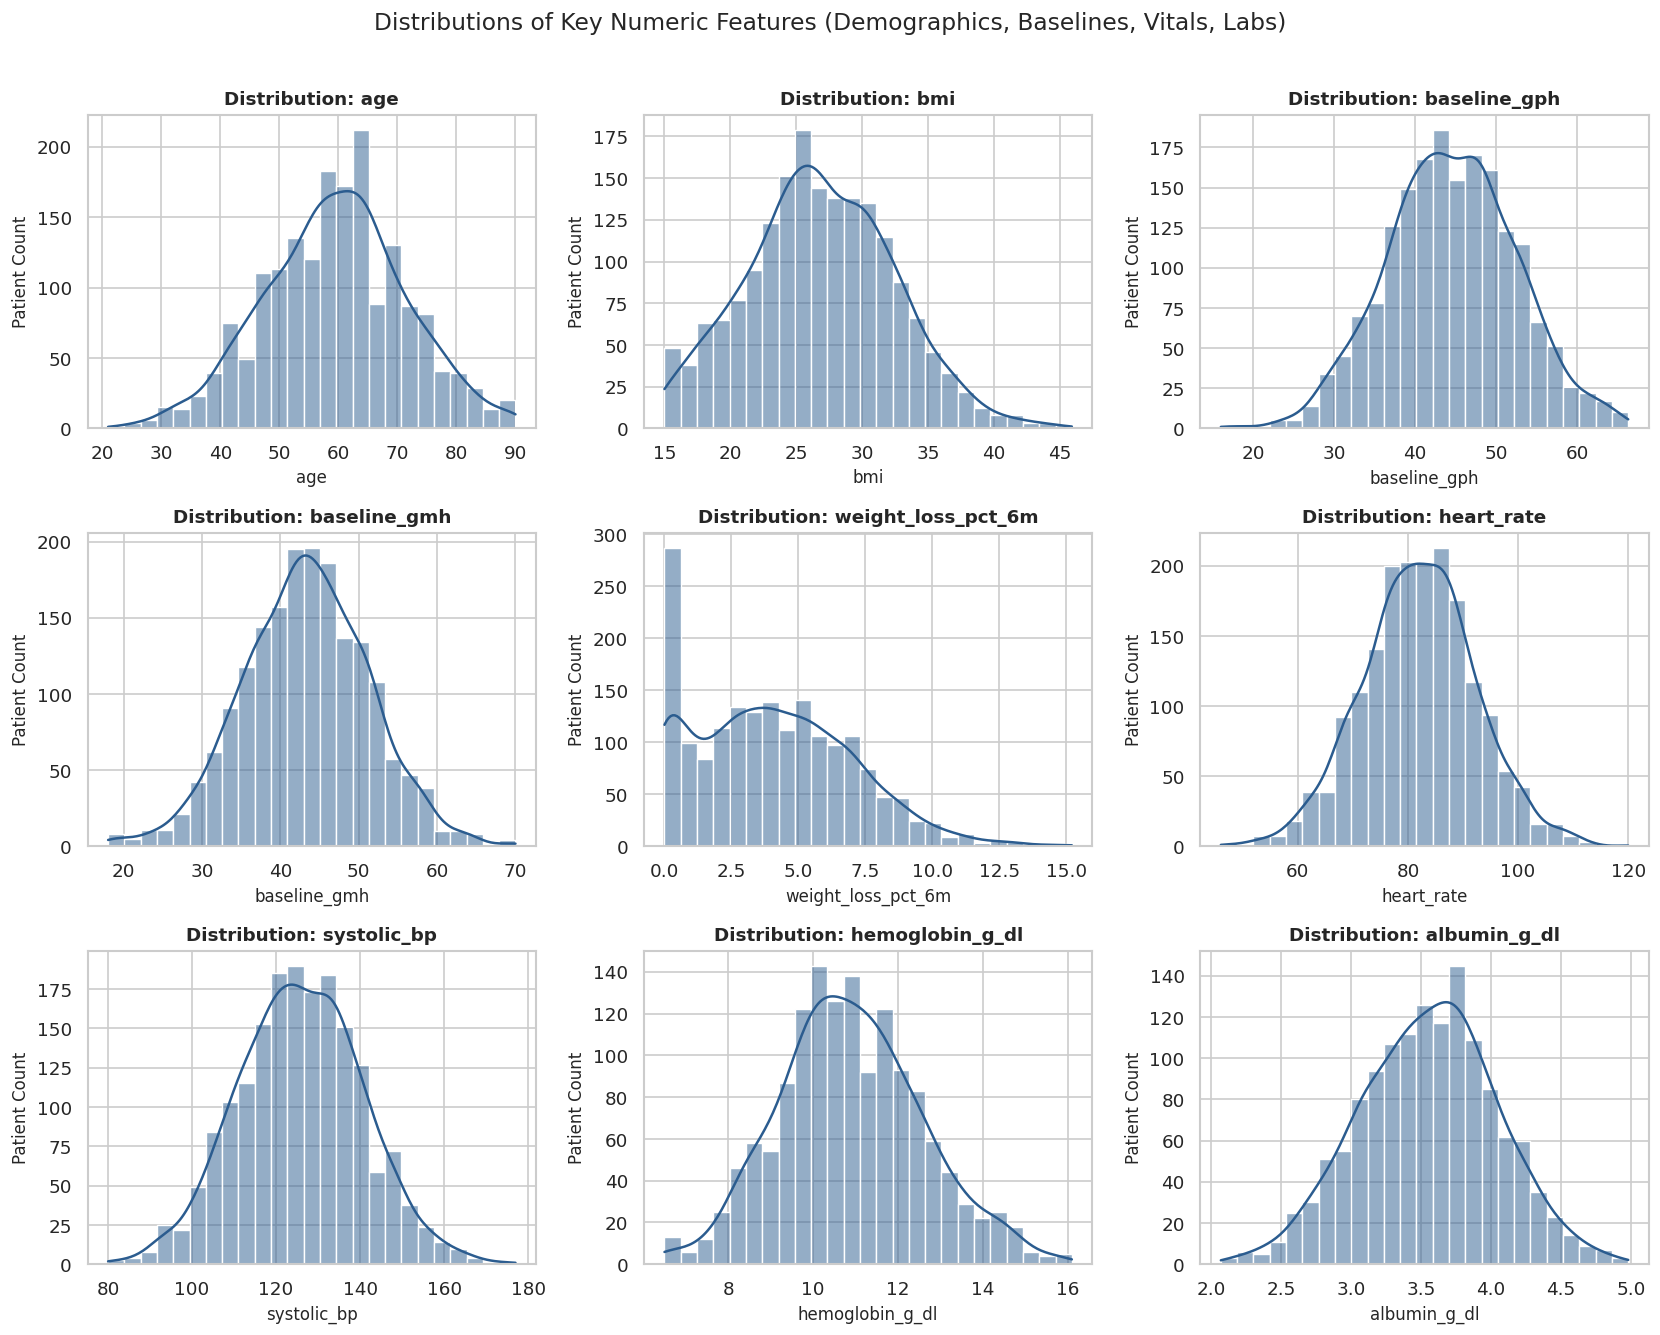

In [9]:
# Create a 3x3 grid of histograms with KDE for key numeric features
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

# Plot histogram and KDE for each selected numeric feature
for i, col in enumerate(key_numeric_features):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[i],
        color="#2b5c8f",
        bins=25
    )
    axes[i].set_title(f"Distribution: {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Patient Count", fontsize=10)

plt.suptitle("Distributions of Key Numeric Features (Demographics, Baselines, Vitals, Labs)", fontsize=14, y=1.01)
plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/03_numeric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: Which numeric features show approximately symmetric (normal) distributions (e.g., baseline GPH, baseline GMH, systolic BP)?*
- *Placeholder: Are baseline PROMIS scores centered below the US general population mean of 50 (hint: check mean of baseline_gph)?*
- *Placeholder: Which features show right-skewness (e.g., weight_loss_pct_6m)?*


# 5. Categorical Features Analysis

### What this section does
In this section, we explore the categorical and ordinal variables in the dataset:
- Oncologic and treatment factors: `cancer_type`, `stage`, `chemo_regimen`, `treatment_intent`, and `ecog_status`.
- Demographic and socioeconomic attributes: `insurance`, `race`, and `smoking_status`.
We print frequency tables and create a multi-panel grid of bar charts to visualize category counts.

### Why we do this
- **Cohort representation**: We need to understand the mix of cancer types (e.g., breast, lung, colorectal, prostate) and treatment protocols in this cohort.
- **Encoding strategy**: Identifying the number of unique categories helps plan future categorical encoding (e.g., one-hot encoding for nominal features like `cancer_type`, ordinal encoding for `stage` and `ecog_status`).
- **Detecting sparse categories**: Identifying rare subgroups (such as ECOG performance status 3 or self-pay insurance) ensures that future train/validation splits maintain adequate representation across all folds.


=== Category Breakdown: cancer_type ===
             Count  Percentage (%)
cancer_type                       
Breast         380            21.1
Lung           321            17.8
Colorectal     266            14.8
Prostate       191            10.6
Lymphoma       180            10.0
Other          179             9.9
Ovarian        147             8.2
Pancreatic     136             7.6

=== Category Breakdown: stage ===
       Count  Percentage (%)
stage                       
3        576            32.0
4        532            29.6
2        483            26.8
1        209            11.6

=== Category Breakdown: ecog_status ===
             Count  Percentage (%)
ecog_status                       
1              840            46.7
0              569            31.6
2              354            19.7
3               37             2.1

=== Category Breakdown: chemo_regimen ===
                       Count  Percentage (%)
chemo_regimen                               
Combination      

C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\804324468.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\804324468.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\804324468.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\804324468.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue

C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\804324468.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\804324468.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


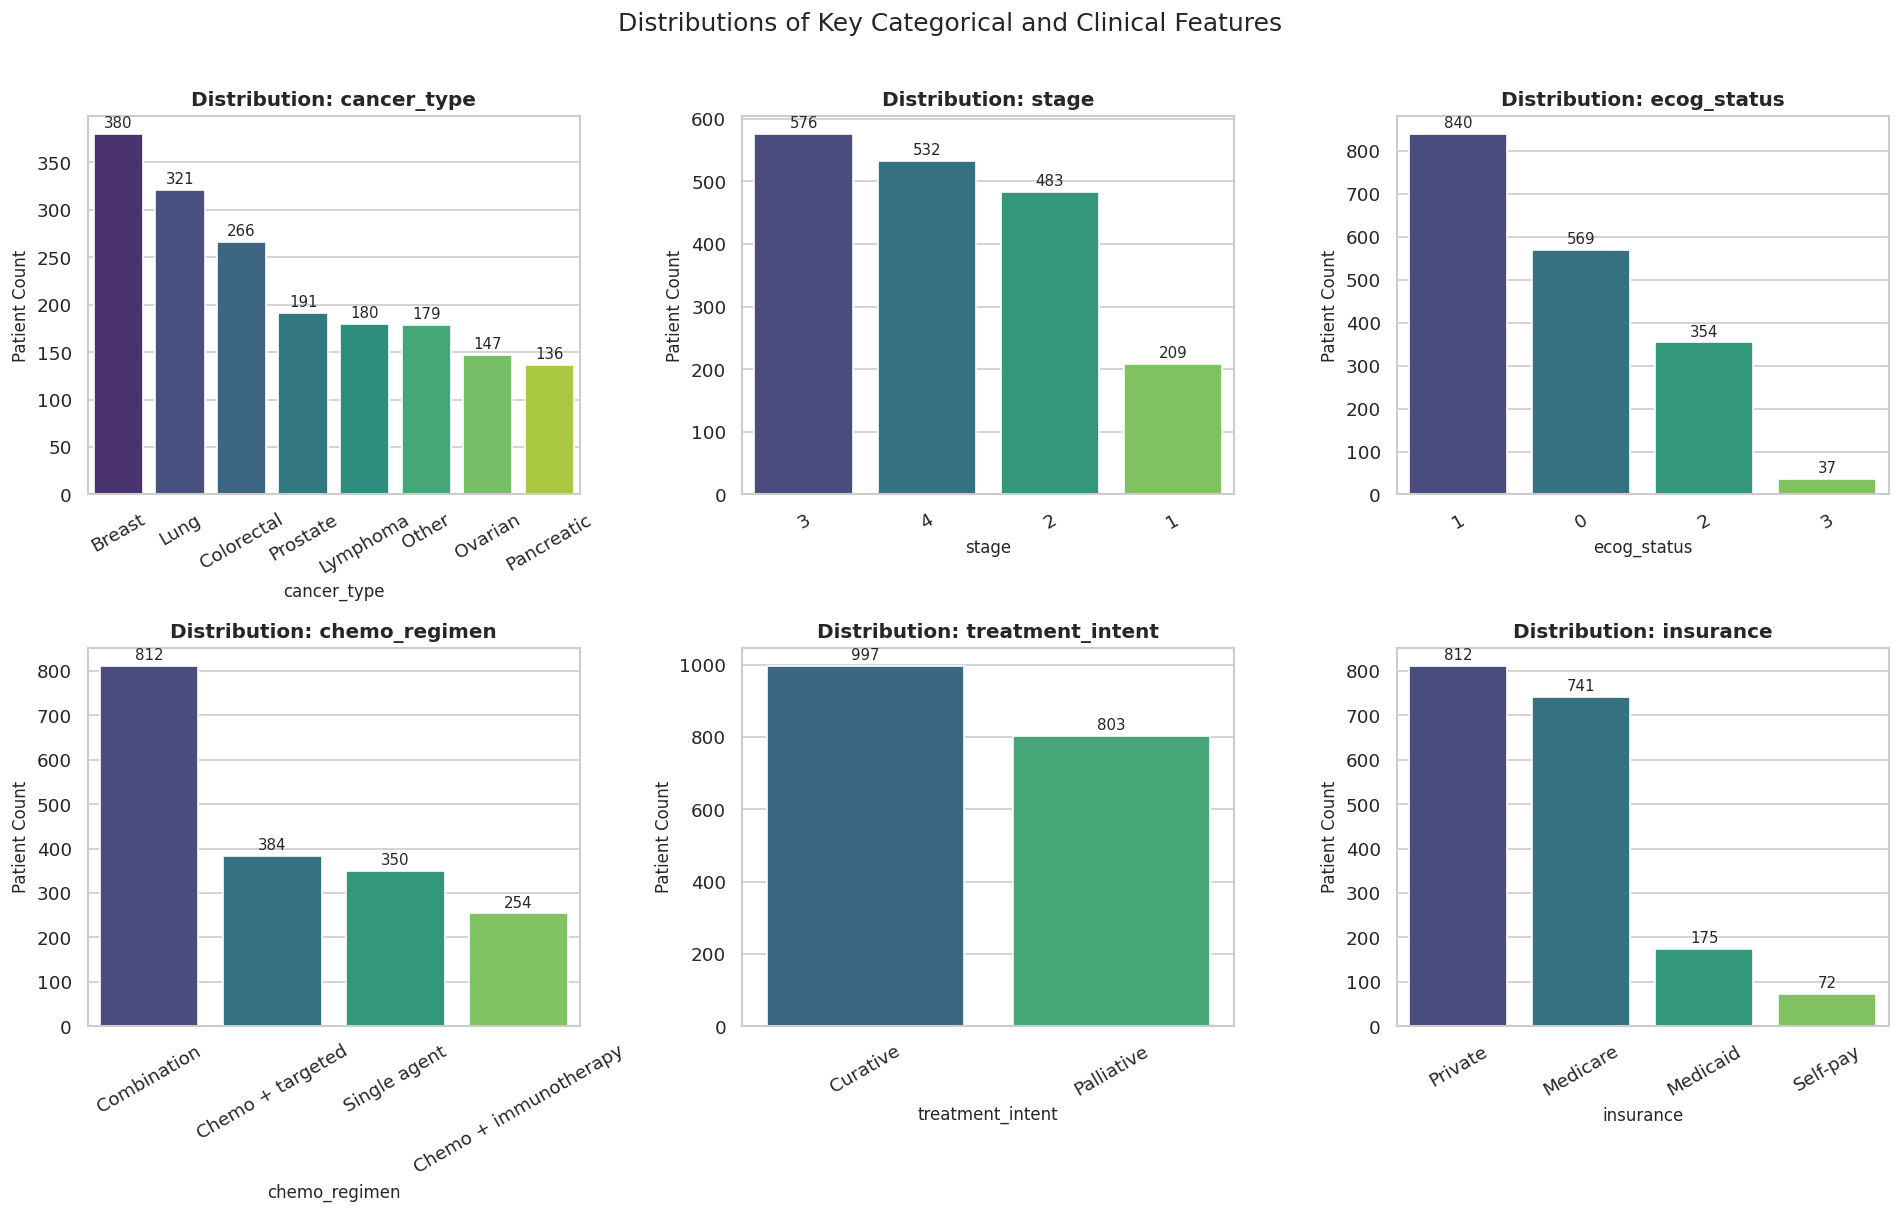

In [10]:
# Select primary categorical and ordinal features to inspect
primary_categorical = [
    "cancer_type", "stage", "ecog_status",
    "chemo_regimen", "treatment_intent", "insurance"
]

# Display value counts and percentages for each feature
for col in primary_categorical:
    print(f"=== Category Breakdown: {col} ===")
    counts = df[col].value_counts()
    percentages = (df[col].value_counts(normalize=True) * 100).round(1)
    summary_cat = pd.DataFrame({"Count": counts, "Percentage (%)": percentages})
    print(summary_cat)
    print()

# Create a 2x3 grid of bar charts
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(primary_categorical):
    # Sort categories by count or natural ordering
    category_order = df[col].value_counts().index
    sns.countplot(
        x=col,
        data=df,
        order=category_order,
        ax=axes[i],
        palette="viridis"
    )
    axes[i].set_title(f"Distribution: {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Patient Count", fontsize=10)
    axes[i].tick_params(axis="x", rotation=30)
    
    # Annotate counts on top of bars
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha="center", va="bottom", fontsize=9, xytext=(0, 2),
                         textcoords="offset points")

plt.suptitle("Distributions of Key Categorical and Clinical Features", fontsize=15, y=1.01)
plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/04_categorical_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: Which cancer types are the most common in this synthetic cohort (e.g., Breast, Lung)?*
- *Placeholder: How are patients distributed across cancer stages (stages 1 through 4)?*
- *Placeholder: What is the distribution of baseline ECOG status (note how few patients have ECOG 3)?*
- *Placeholder: What percentage of patients have curative versus palliative treatment intent?*


# 6. Relationships with the Target (`drop_outcome`)

### What this section does
In this section, we investigate bivariate relationships between candidate clinical features and the primary outcome, `drop_outcome`:
1. **Drop rate across clinical categories**: We calculate and plot the percentage of patients experiencing a 10+ point drop in GPH stratified by `cancer_type`, `stage`, `ecog_status`, and `chemo_regimen`.
2. **Distribution differences for continuous features**: We generate boxplots comparing `baseline_gph` and patient `age` between patients who experienced a drop (`drop_outcome = 1`) and those who did not (`drop_outcome = 0`).

### Why we do this
- **Discovering predictive clinical signals**: Comparing the rate of physical health decline across clinical subgroups highlights which features carry the strongest predictive value for chemotherapy toxicity.
- **Validating oncologic intuition**: Clinical literature (such as Ostberg & Peterson) indicates that advanced stage and higher ECOG performance status (greater pre-existing functional limitation) correlate strongly with physical deterioration on chemotherapy.
- **Baseline score dynamics**: Checking baseline GPH helps evaluate whether patients entering chemotherapy with higher physical scores have "more room to drop" or whether frail patients drop more frequently.


C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\517627293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\517627293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\517627293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\517627293.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

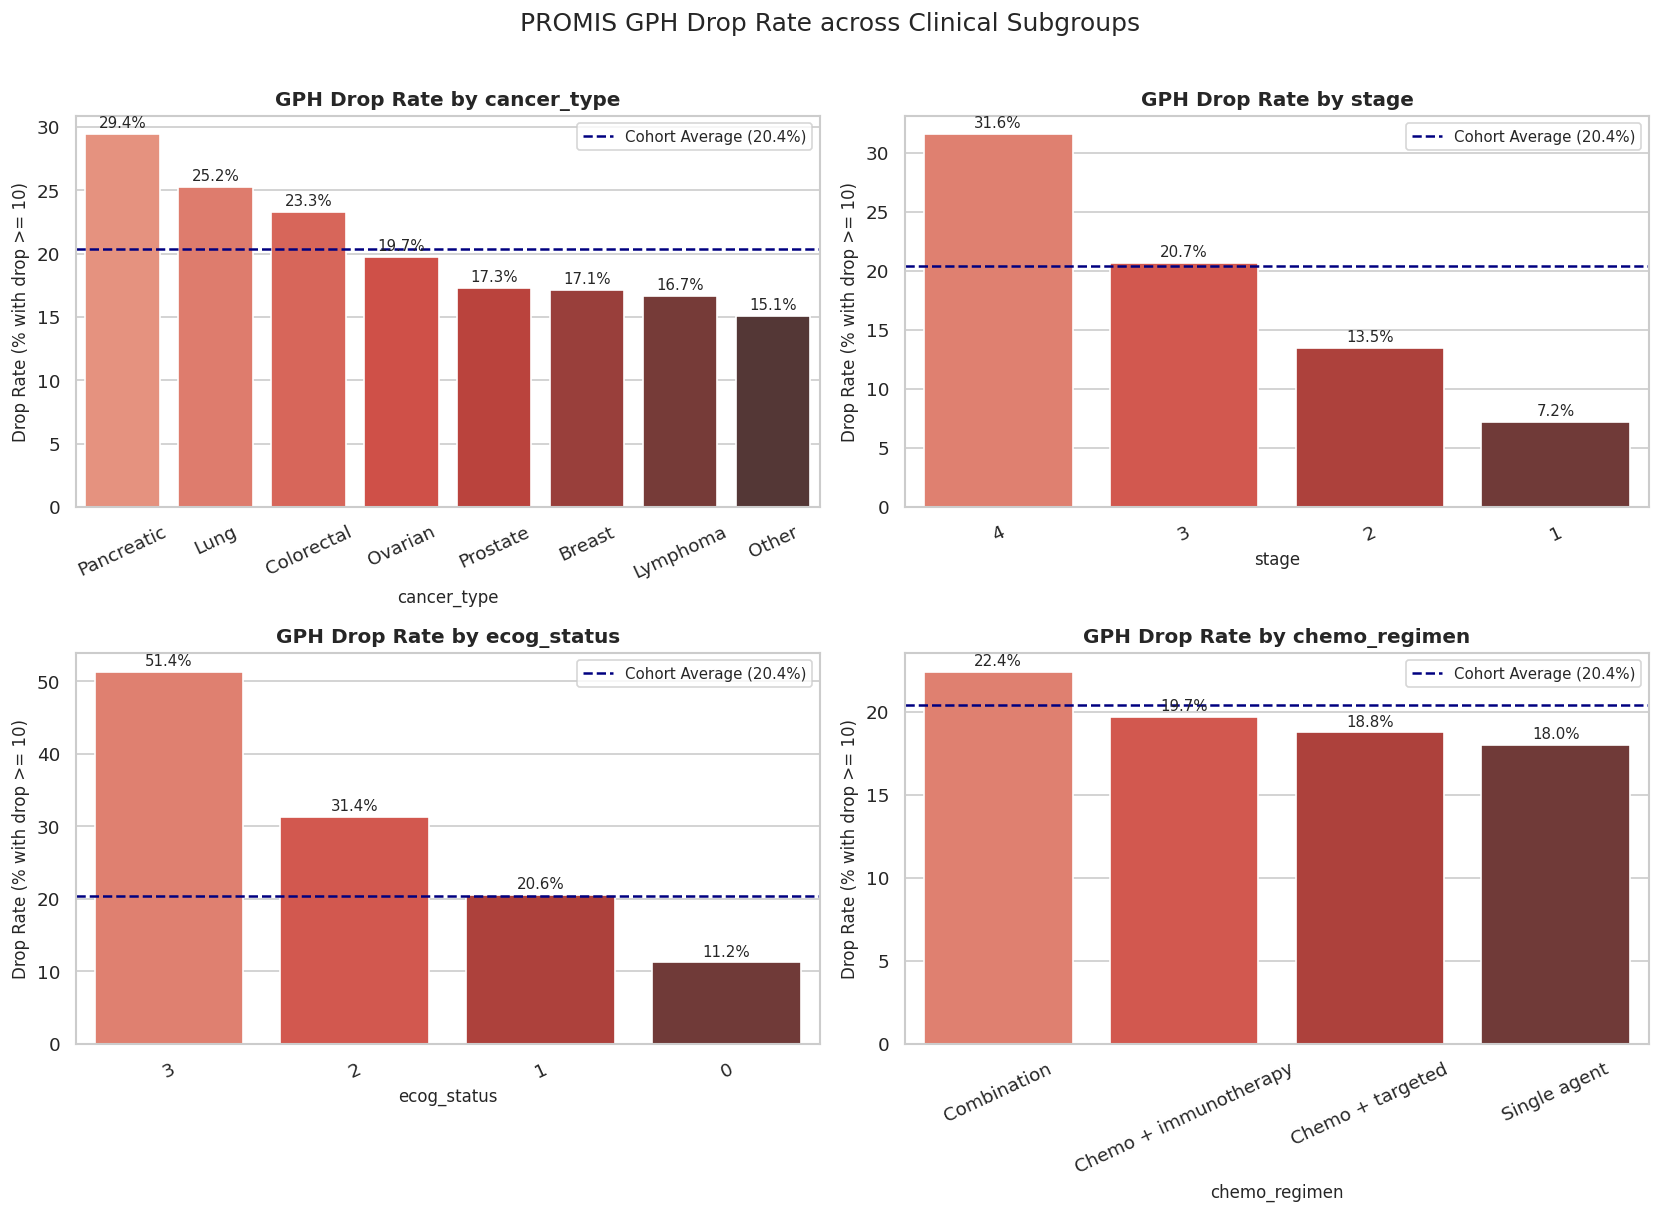

In [11]:
# Calculate the overall cohort drop rate for benchmark comparison
overall_drop_rate = df["drop_outcome"].mean() * 100

# Key clinical factors to evaluate
clinical_subgroups = ["cancer_type", "stage", "ecog_status", "chemo_regimen"]

# Create a 2x2 grid of bar charts for drop rates
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(clinical_subgroups):
    # Calculate drop rate (%) for each category
    rate_series = (df.groupby(col)["drop_outcome"].mean() * 100).sort_values(ascending=False)
    
    # Plot bar chart
    sns.barplot(
        x=rate_series.index.astype(str),
        y=rate_series.values,
        ax=axes[i],
        palette="Reds_d"
    )
    # Add horizontal reference line for overall cohort drop rate
    axes[i].axhline(
        overall_drop_rate, color="navy", linestyle="--", linewidth=1.5,
        label=f"Cohort Average ({overall_drop_rate:.1f}%)"
    )
    
    axes[i].set_title(f"GPH Drop Rate by {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Drop Rate (% with drop >= 10)", fontsize=10)
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].legend(loc="upper right", fontsize=9)
    
    # Add percentage text labels on top of each bar
    for p in axes[i].patches:
        val = p.get_height()
        axes[i].annotate(f"{val:.1f}%",
                         (p.get_x() + p.get_width() / 2., val),
                         ha="center", va="bottom", fontsize=9, xytext=(0, 2),
                         textcoords="offset points")

plt.suptitle("PROMIS GPH Drop Rate across Clinical Subgroups", fontsize=15, y=1.01)
plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/05_drop_rate_by_clinical_features.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: How does the drop rate progress from Stage 1 (7.2%) up through Stage 4 (31.6%)?*
- *Placeholder: How does the drop rate scale across ECOG performance status (ECOG 0 at 11.2% vs ECOG 3 at 51.4%)?*
- *Placeholder: Which cancer types have the highest drop rates (e.g., Pancreatic at ~29.4%, Lung at ~25.2%)?*
- *Placeholder: How does combination chemotherapy compare to single-agent chemotherapy?*


C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\3353618233.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\3353618233.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["0: No Drop (<10 pts)", "1: Drop (>=10 pts)"])
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\3353618233.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\3353618233.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[

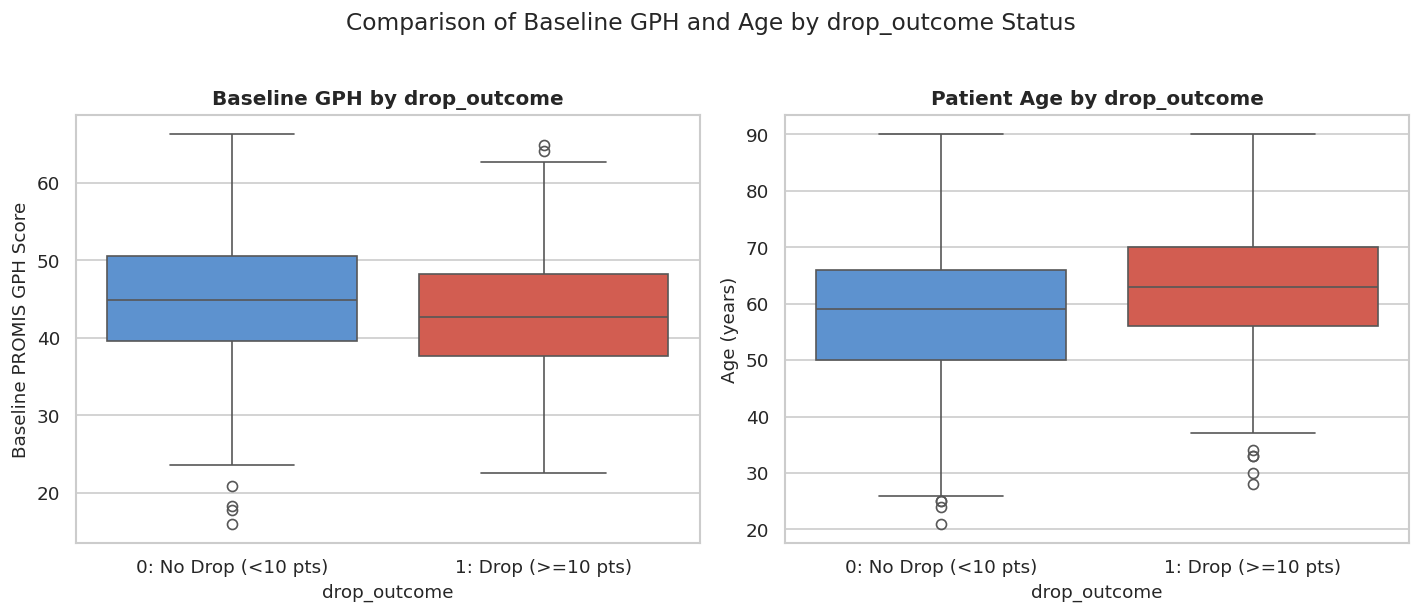

In [12]:
# Create side-by-side boxplots comparing baseline_gph and age across drop_outcome classes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: baseline_gph by drop_outcome
sns.boxplot(
    x="drop_outcome",
    y="baseline_gph",
    data=df,
    ax=axes[0],
    palette=["#4a90e2", "#e74c3c"]
)
axes[0].set_title("Baseline GPH by drop_outcome", fontsize=12, fontweight="bold")
axes[0].set_xlabel("drop_outcome", fontsize=11)
axes[0].set_ylabel("Baseline PROMIS GPH Score", fontsize=11)
axes[0].set_xticklabels(["0: No Drop (<10 pts)", "1: Drop (>=10 pts)"])

# Plot 2: age by drop_outcome
sns.boxplot(
    x="drop_outcome",
    y="age",
    data=df,
    ax=axes[1],
    palette=["#4a90e2", "#e74c3c"]
)
axes[1].set_title("Patient Age by drop_outcome", fontsize=12, fontweight="bold")
axes[1].set_xlabel("drop_outcome", fontsize=11)
axes[1].set_ylabel("Age (years)", fontsize=11)
axes[1].set_xticklabels(["0: No Drop (<10 pts)", "1: Drop (>=10 pts)"])

plt.suptitle("Comparison of Baseline GPH and Age by drop_outcome Status", fontsize=14, y=1.02)
plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/06_boxplots_by_drop_outcome.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: How do median baseline GPH scores compare between patients who dropped vs those who did not?*
- *Placeholder: Is there a noticeable shift in patient age between patients with and without decline?*
- *Placeholder: Are there outliers in either group?*


# 7. Correlation Analysis: Top Features Correlated with `drop_outcome`

### What this section does
In this section, we analyze the linear (Pearson) correlations between numerical candidate features and `drop_outcome`:
1. We compute correlation coefficients for all valid numerical predictors.
2. We identify the **top 10 candidate features** most strongly correlated with `drop_outcome` (by absolute value) and visualize their correlation values with a horizontal bar plot.
3. We plot a **correlation heatmap** showing pairwise relationships between these top 10 features and `drop_outcome`.

### Why we do this
- **Feature importance signal**: Identifies which laboratory values, vitals, comorbidities, and baseline scores have the strongest linear association with physical decline.
- **Multicollinearity assessment**: High correlations between pairs of predictor variables (e.g., stage and ECOG, or albumin and hemoglobin) alert us to potential collinearity in linear and logistic regression models.
- **Strict Data Leakage Prevention**: We deliberately exclude `on_chemo_gph` and `threshold_outcome` from the candidate feature list. Because `on_chemo_gph` is collected *during* chemotherapy and was used to define `drop_outcome`, treating it as an input predictor would constitute **data leakage** and create an unrealistically accurate, clinically useless model.


=== Top 10 Candidate Numeric Features Correlated with drop_outcome ===
           Feature  Pearson Correlation (r)  Absolute Correlation (|r|)
      albumin_g_dl                   -0.248                       0.248
   hemoglobin_g_dl                   -0.217                       0.217
      baseline_gmh                   -0.208                       0.208
             stage                    0.206                       0.206
       ecog_status                    0.204                       0.204
 num_comorbidities                    0.161                       0.161
               age                    0.143                       0.143
weight_loss_pct_6m                    0.132                       0.132
              spo2                   -0.115                       0.115
      baseline_gph                   -0.110                       0.110


C:\Users\abhi1\AppData\Local\Temp\ipykernel_2712\2590517749.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


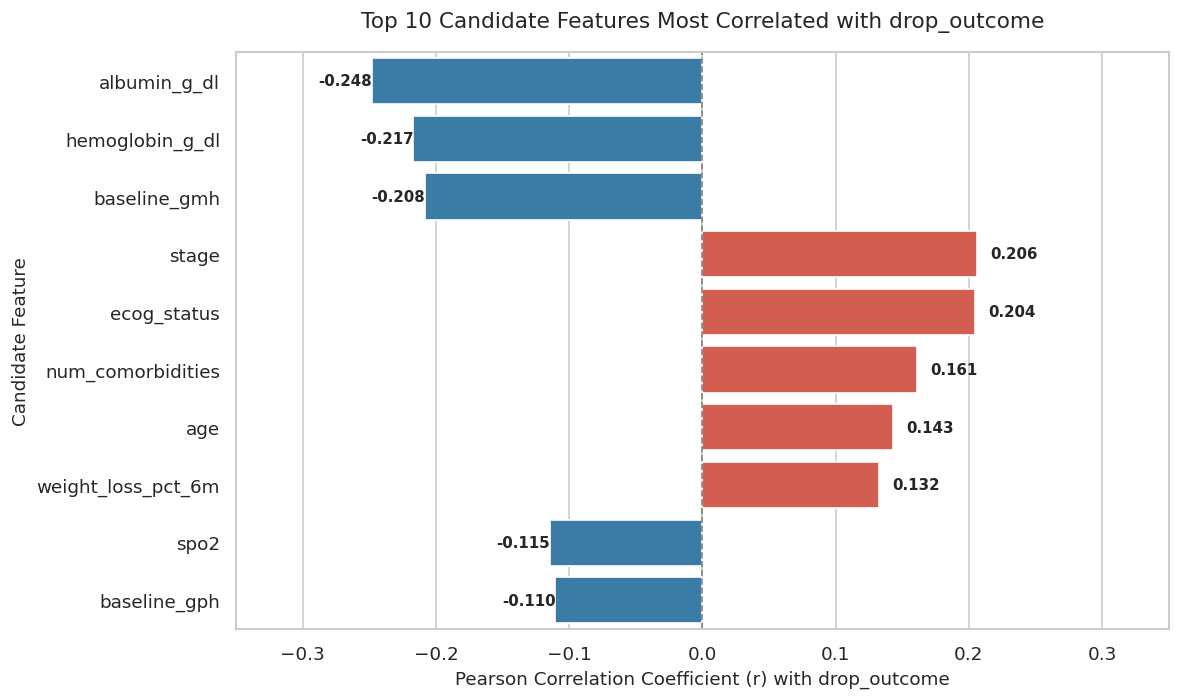

In [13]:
# Select all numeric columns in the dataset
all_numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Identify non-feature columns that MUST NOT be used as candidate predictors:
# - patient_id (record identifier)
# - drop_outcome (the target itself)
# - threshold_outcome (alternative outcome label)
# - on_chemo_gph (DATA LEAKAGE: post-treatment outcome measurement!)
excluded_cols = ["patient_id", "drop_outcome", "threshold_outcome", "on_chemo_gph"]
candidate_num_cols = [c for c in all_numeric_cols if c not in excluded_cols]

# Compute Pearson correlation of each candidate numeric feature with drop_outcome
corrs = df[candidate_num_cols].corrwith(df["drop_outcome"])

# Find top 10 features by absolute correlation magnitude
top_10_abs_indices = corrs.abs().sort_values(ascending=False).head(10).index
top_10_corrs = corrs[top_10_abs_indices]

# Display summary table of the top 10 features
print("=== Top 10 Candidate Numeric Features Correlated with drop_outcome ===")
top_10_summary = pd.DataFrame({
    "Feature": top_10_corrs.index,
    "Pearson Correlation (r)": top_10_corrs.values.round(3),
    "Absolute Correlation (|r|)": top_10_corrs.abs().values.round(3)
})
print(top_10_summary.to_string(index=False))

# Plot horizontal bar chart of the top 10 correlations
plt.figure(figsize=(10, 6))

# Assign red for positive correlation (increases risk) and blue for negative correlation (protective)
bar_colors = ["#e74c3c" if r > 0 else "#2980b9" for r in top_10_corrs.values]

sns.barplot(
    x=top_10_corrs.values,
    y=top_10_corrs.index,
    palette=bar_colors
)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Top 10 Candidate Features Most Correlated with drop_outcome", fontsize=13, pad=15)
plt.xlabel("Pearson Correlation Coefficient (r) with drop_outcome", fontsize=11)
plt.ylabel("Candidate Feature", fontsize=11)
plt.xlim(-0.35, 0.35)

# Annotate correlation values on the bars
for idx, val in enumerate(top_10_corrs.values):
    offset = 0.01 if val >= 0 else -0.04
    plt.text(val + offset, idx, f"{val:.3f}", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/07_top_correlations_with_drop_outcome.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: Which laboratory markers show the strongest negative correlation with drop (e.g., serum albumin, hemoglobin)? What does low albumin reflect clinically (e.g., malnutrition, cachexia)?*
- *Placeholder: Which clinical features show the strongest positive correlation with drop (e.g., cancer stage, ECOG status, number of comorbidities, age)?*
- *Placeholder: How does baseline mental health (`baseline_gmh`) correlate with physical decline?*


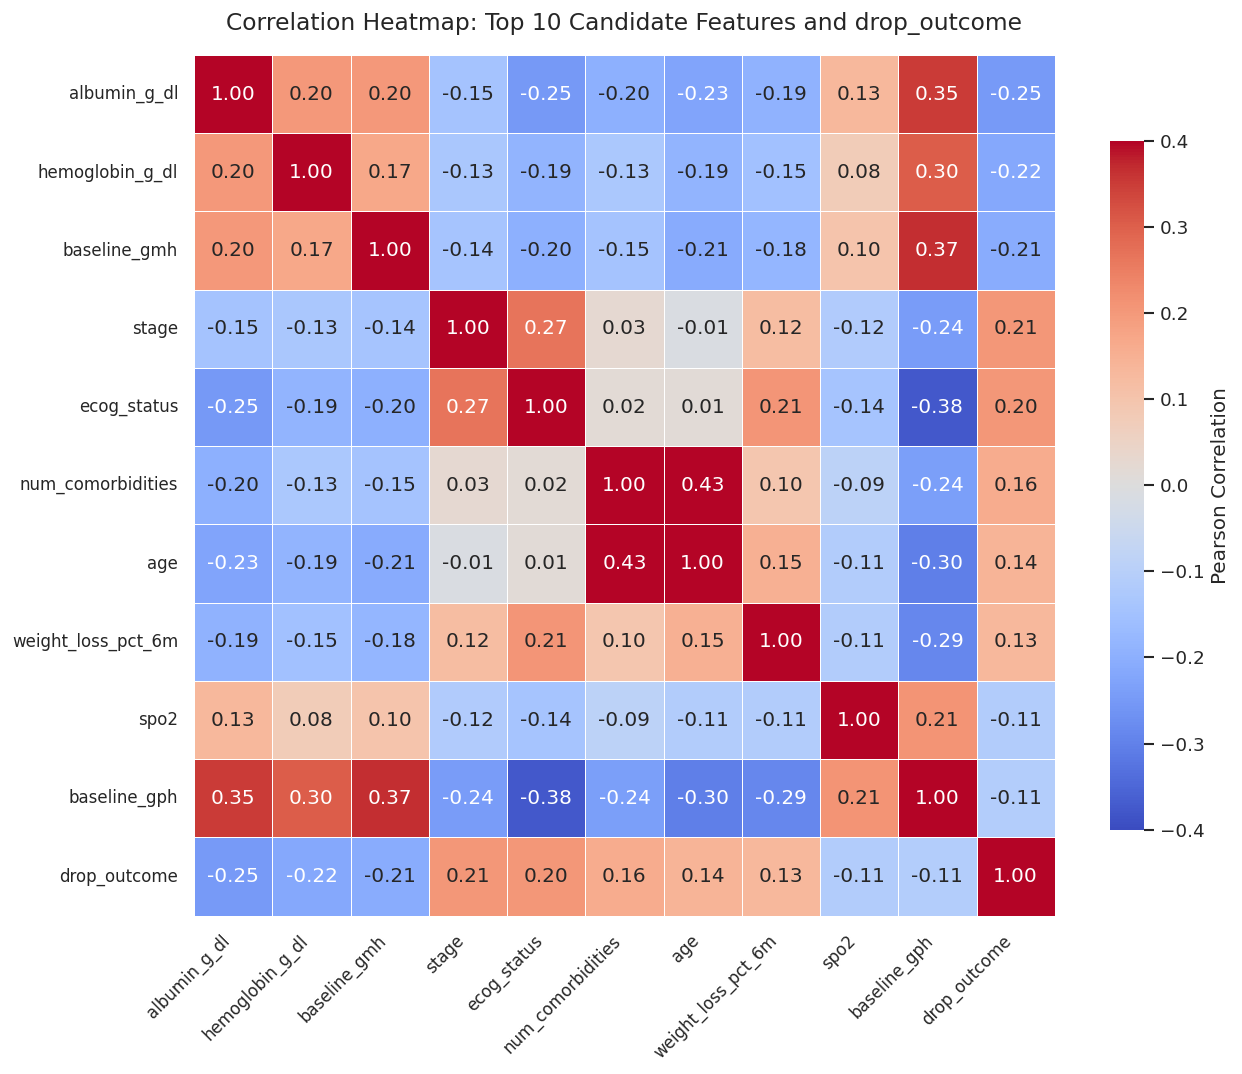

In [14]:
# Select the top 10 features plus drop_outcome for the correlation matrix heatmap
heatmap_columns = list(top_10_corrs.index) + ["drop_outcome"]
corr_matrix = df[heatmap_columns].corr()

# Plot the correlation heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-0.4,
    vmax=0.4,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"}
)
plt.title("Correlation Heatmap: Top 10 Candidate Features and drop_outcome", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/08_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: Are any predictor variables correlated with each other (e.g., stage vs ecog_status, or albumin vs hemoglobin)?*
- *Placeholder: Are correlations among predictors moderate enough that collinearity will not disrupt tree-based or regularized models?*


# 8. Distribution of `baseline_gph` vs `on_chemo_gph`

### What this section does
In this final section, we analyze the distribution of PROMIS Global Physical Health before starting chemotherapy (`baseline_gph`) versus during chemotherapy (`on_chemo_gph`):
1. **Distribution shift**: We compute summary statistics for both scores, calculate the individual patient score change ($on\_chemo\_gph - baseline\_gph$), and plot overlapping histograms and KDE density curves.
2. **Clinical decision boundary visualization**: We plot a scatter plot of `baseline_gph` vs `on_chemo_gph` colored by `drop_outcome`, and overlay key clinical reference lines:
   - Line of no change ($y = x$)
   - 10-point drop boundary ($y = x - 10$)
   - Absolute impairment threshold ($y = 40$)

### Why we do this
- **Quantifying treatment burden**: Chemotherapy imposes significant toxicity. Comparing baseline and on-treatment distributions quantifies the overall downward shift in patient physical well-being across the cohort.
- **Visualizing outcome logic**: Seeing individual patients plotted against $y = x - 10$ and $y = 40$ provides concrete visual verification of how `drop_outcome` and `threshold_outcome` operate:
  - All red points (`drop_outcome = 1`) lie on or below the line $y = x - 10$.
  - All patients with on-chemotherapy scores $\le 40$ lie on or below the horizontal line $y = 40$.
- **Solidifying data leakage understanding**: This comparison emphasizes that `on_chemo_gph` is an observation of the *effect* of chemotherapy, not a predictor available before treatment begins.


=== Descriptive Statistics: Baseline GPH vs On-Chemo GPH ===
       baseline_gph  on_chemo_gph  gph_change (on_chemo - baseline)
count       1800.00       1800.00                           1800.00
mean          44.50         40.21                             -4.28
std            7.94         11.45                              7.03
min           16.00         10.00                            -25.90
25%           39.10         32.70                             -8.90
50%           44.40         40.05                             -4.20
75%           49.80         48.10                              0.60
max           66.30         70.00                             18.80


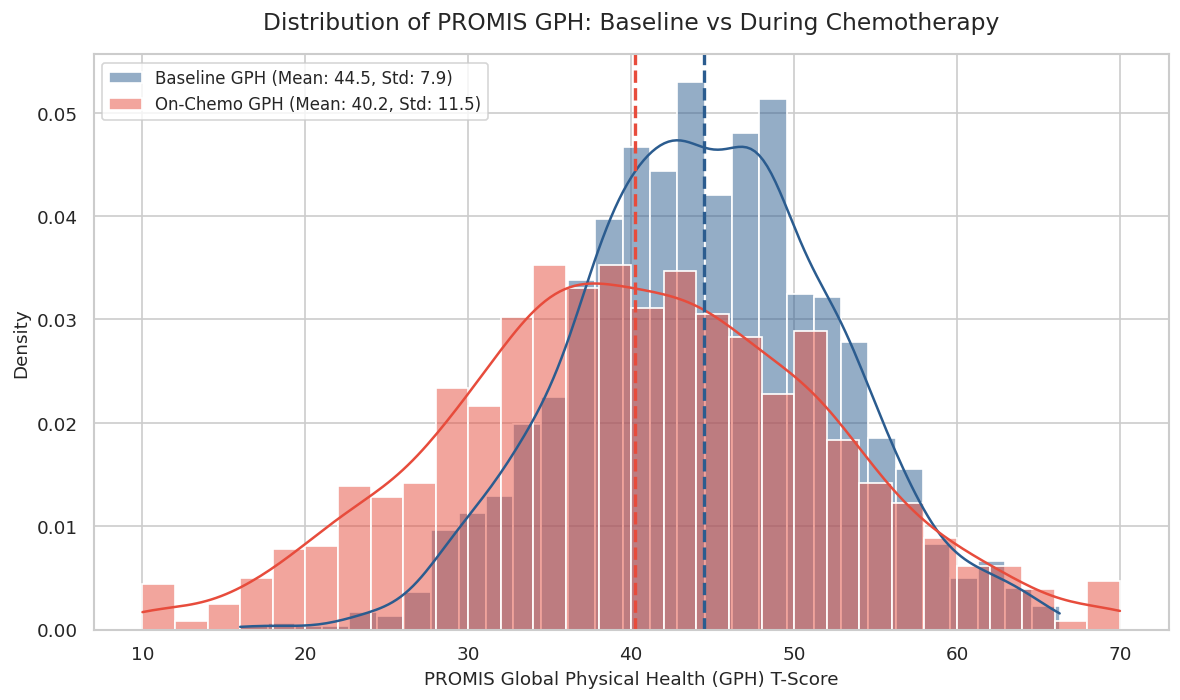

In [15]:
# Calculate the change in PROMIS GPH for each patient
gph_change = df["on_chemo_gph"] - df["baseline_gph"]

# Compute and display descriptive statistics comparing baseline, on-chemo, and the delta
print("=== Descriptive Statistics: Baseline GPH vs On-Chemo GPH ===")
gph_comparison = pd.DataFrame({
    "baseline_gph": df["baseline_gph"].describe(),
    "on_chemo_gph": df["on_chemo_gph"].describe(),
    "gph_change (on_chemo - baseline)": gph_change.describe()
}).round(2)
print(gph_comparison)

# Plot overlapping histogram and KDE distributions
plt.figure(figsize=(10, 6))

sns.histplot(
    df["baseline_gph"],
    color="#2b5c8f",
    kde=True,
    stat="density",
    bins=30,
    label=f"Baseline GPH (Mean: {df['baseline_gph'].mean():.1f}, Std: {df['baseline_gph'].std():.1f})"
)

sns.histplot(
    df["on_chemo_gph"],
    color="#e74c3c",
    kde=True,
    stat="density",
    bins=30,
    label=f"On-Chemo GPH (Mean: {df['on_chemo_gph'].mean():.1f}, Std: {df['on_chemo_gph'].std():.1f})"
)

# Add vertical dashed lines indicating group means
plt.axvline(df["baseline_gph"].mean(), color="#2b5c8f", linestyle="--", linewidth=2)
plt.axvline(df["on_chemo_gph"].mean(), color="#e74c3c", linestyle="--", linewidth=2)

plt.title("Distribution of PROMIS GPH: Baseline vs During Chemotherapy", fontsize=14, pad=15)
plt.xlabel("PROMIS Global Physical Health (GPH) T-Score", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/09_baseline_vs_on_chemo_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: How much did the mean PROMIS GPH score decline during chemotherapy (from 44.5 to 40.2)?*
- *Placeholder: How does the standard deviation change from baseline (7.9) to on-chemo (11.5)? Why might variance increase during chemotherapy?*
- *Placeholder: What percentage of patients experienced a negative change in their GPH score?*


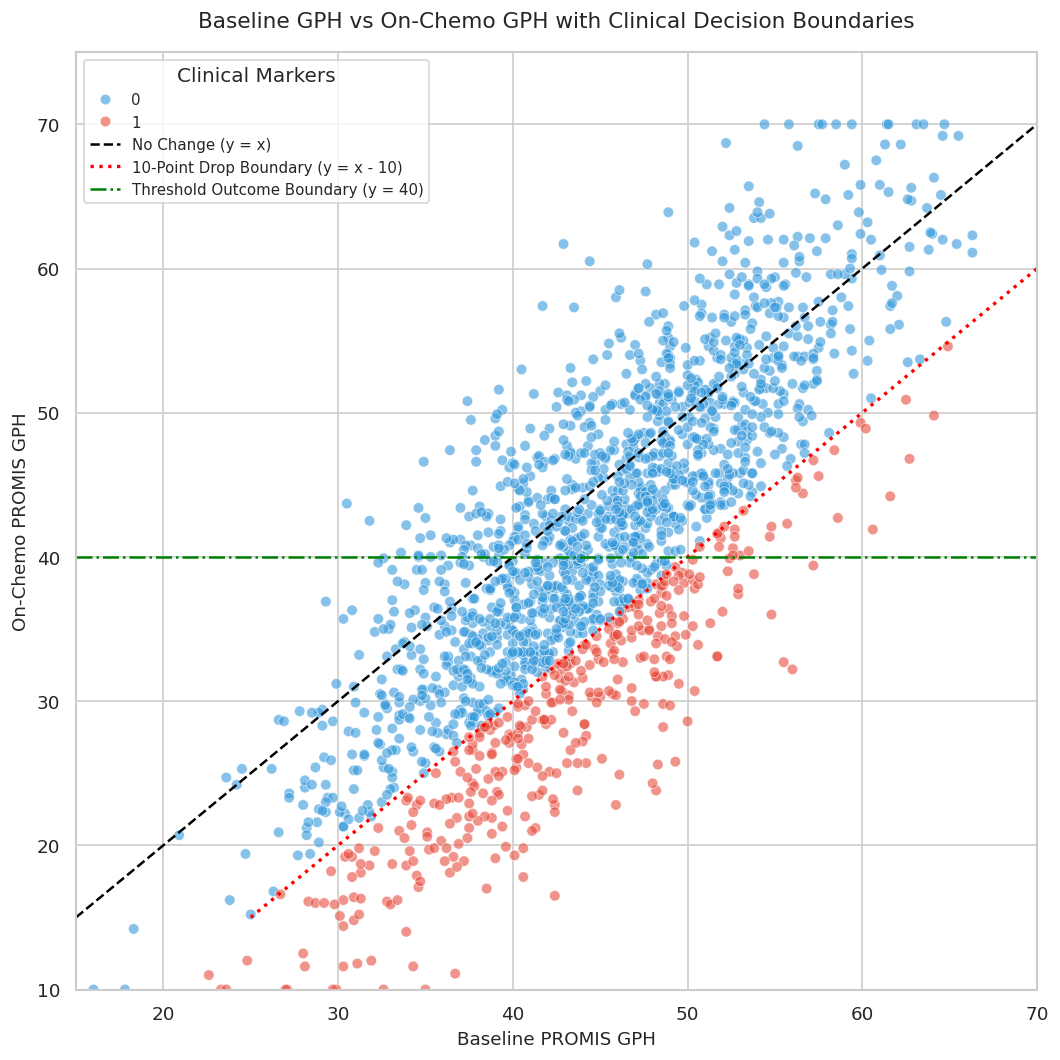

In [16]:
# Create scatter plot comparing baseline_gph vs on_chemo_gph with clinical decision boundaries
plt.figure(figsize=(9, 9))

# Scatter plot of individual patients colored by drop_outcome
sns.scatterplot(
    x="baseline_gph",
    y="on_chemo_gph",
    hue="drop_outcome",
    palette=["#3498db", "#e74c3c"],
    alpha=0.6,
    data=df,
    s=40
)

# Reference Line 1: Line of no change (y = x)
plt.plot([15, 70], [15, 70], color="black", linestyle="--", linewidth=1.5, label="No Change (y = x)")

# Reference Line 2: 10-point drop boundary (y = x - 10)
plt.plot([25, 70], [15, 60], color="red", linestyle=":", linewidth=2, label="10-Point Drop Boundary (y = x - 10)")

# Reference Line 3: Absolute threshold boundary (y = 40)
plt.axhline(40, color="green", linestyle="-.", linewidth=1.5, label="Threshold Outcome Boundary (y = 40)")

plt.title("Baseline GPH vs On-Chemo GPH with Clinical Decision Boundaries", fontsize=13, pad=15)
plt.xlabel("Baseline PROMIS GPH", fontsize=11)
plt.ylabel("On-Chemo PROMIS GPH", fontsize=11)
plt.xlim(15, 70)
plt.ylim(10, 75)

# Customize legend with informative labels
plt.legend(title="Clinical Markers", loc="upper left", frameon=True, fontsize=9)
plt.tight_layout()

# Save the figure to the reports directory
plt.savefig("../reports/figures/10_baseline_vs_on_chemo_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


### What I noticed:
- *Placeholder: Confirm that all points with `drop_outcome = 1` (red) lie on or below the red dotted line ($y = x - 10$).*
- *Placeholder: Confirm that all points on or below the green dash-dotted line ($y = 40$) represent `threshold_outcome = 1`.*
- *Placeholder: Notice how some patients start with high baseline GPH (>55) and experience a 10+ point drop while remaining above 40.*
- *Placeholder: Notice how some patients start with low baseline GPH (<45) and cross below 40 with only a modest drop.*
